# Datathon Passos Mágicos — Análise Exploratória (Perguntas 1 a 11)

Este notebook responde às 11 perguntas de negócio do desafio, usando a base **PEDE 2022-2024**
já limpa (ver notebook `01_limpeza_dados_PEDE.ipynb`).

**Como este notebook está organizado:**
- Seção 0: carga dos dados limpos (ou, se preferir, a limpeza é refeita aqui do zero, então o
  notebook funciona sozinho mesmo sem rodar o de limpeza antes)
- Seções 1 a 11: uma por pergunta, com código + gráfico + interpretação em texto

**Sobre os indicadores** (fórmulas conforme documento "PEDE — Pontos importantes" e dicionário de
dados da Passos Mágicos):
- **IAN** (Adequação de Nível): calculado a partir da defasagem `D = Fase Efetiva − Fase Ideal`
- **IDA** (Desempenho Acadêmico): média de Matemática, Português e Inglês
- **IEG** (Engajamento): média das pontuações de tarefas/atividades realizadas
- **IAA** (Autoavaliação): média das respostas do próprio aluno
- **IPS** (Psicossocial): média das avaliações da equipe de psicologia
- **IPP** (Psicopedagógico): média das avaliações pedagógicas
- **IPV** (Ponto de Virada): síntese longitudinal de progresso acadêmico/engajamento/emocional
- **INDE**: índice geral, ponderação de todos os indicadores acima

> **Limitação conhecida:** a coluna booleana `Atingiu PV` (se o aluno atingiu o Ponto de Virada)
> só está preenchida na aba de 2022 — em 2023/2024 ela vem 100% vazia na planilha original. Por
> isso, para 2023 e 2024 usamos o **score IPV contínuo** como proxy, em vez do indicador booleano.

> **Rodando no Google Colab?** A célula abaixo clona o repositório automaticamente e ajusta o diretório de trabalho — não precisa fazer nada manualmente, só executar as células em ordem, de cima para baixo.

In [ ]:
import os

# Detecta se está rodando no Google Colab. Se estiver, clona o repositório (ou entra
# nele, se já tiver sido clonado nesta sessão) e muda o diretório de trabalho para
# dentro de notebooks/ -- assim todo o resto do notebook (que usa caminhos relativos
# à pasta notebooks/) funciona igual, esteja você no Colab, no Jupyter local ou em
# qualquer outro ambiente.
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_URL = "https://github.com/juliamchaves/dathatonfiap.git"
    REPO_DIR = "/content/dathatonfiap"

    if not os.path.exists(REPO_DIR):
        get_ipython().system(f"git clone {REPO_URL} {REPO_DIR}")
    else:
        # Repositório já clonado nesta sessão -- só atualiza (não recloná do zero).
        get_ipython().system(f"cd {REPO_DIR} && git pull")

    os.chdir(f"{REPO_DIR}/notebooks")
    print("Rodando no Colab -- diretório de trabalho:", os.getcwd())
else:
    print("Rodando fora do Colab -- usando os arquivos locais do repositório clonado.")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 0. Carga dos dados

Se o arquivo `PEDE_consolidado_longo.csv` (gerado pelo notebook de limpeza) já existir na sua
pasta, ele é usado diretamente. Caso contrário, a limpeza é refeita aqui a partir do Excel bruto,
para que este notebook funcione de forma independente.

In [ ]:
from pathlib import Path

import pandas as pd

# A celula de bootstrap do Colab (logo acima) ja garante que o diretorio de trabalho
# seja notebooks/, esteja voce no Colab ou localmente -- entao este caminho relativo
# funciona nos dois casos.
RAIZ_PROJETO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CLEAN_CSV = RAIZ_PROJETO / "data" / "raw" / "PEDE_consolidado_longo.csv"

df = pd.read_csv(CLEAN_CSV)

print(f"Base carregada com {df.shape[0]} linhas e {df.shape[1]} colunas.")


Base carregada com 3030 linhas e 25 colunas.


In [ ]:

def categoriza_defasagem(d):
    if pd.isna(d):
        return np.nan
    if d >= 0:
        return "Adequado/Adiantado"
    if d >= -2:
        return "Moderadamente defasado"
    return "Severamente defasado"

df["Cat_Defasagem"] = df["Defasagem"].apply(categoriza_defasagem)
df[["Ano", "RA", "Defasagem", "IAN", "Cat_Defasagem"]].head()

,Ano,RA,Defasagem,IAN,Cat_Defasagem
0,2022,RA-1,-1,5.0,Moderadamente defasado
1,2022,RA-2,0,10.0,Adequado/Adiantado
2,2022,RA-3,0,10.0,Adequado/Adiantado
3,2022,RA-4,0,10.0,Adequado/Adiantado
4,2022,RA-5,0,10.0,Adequado/Adiantado


---
## 1. Adequação do nível (IAN) — perfil geral e evolução

`IAN` é definido a partir da defasagem `D = Fase Efetiva − Fase Ideal`. Classificamos:
- **Adequado/Adiantado**: D ≥ 0
- **Moderadamente defasado**: D entre -1 e -2
- **Severamente defasado**: D ≤ -3

Cat_Defasagem  Adequado/Adiantado  Moderadamente defasado  \
Ano                                                         
2022                         30.1                    66.6   
2023                         45.6                    53.1   
2024                         53.8                    45.9   

Cat_Defasagem  Severamente defasado  
Ano                                  
2022                            3.3  
2023                            1.4  
2024                            0.3  


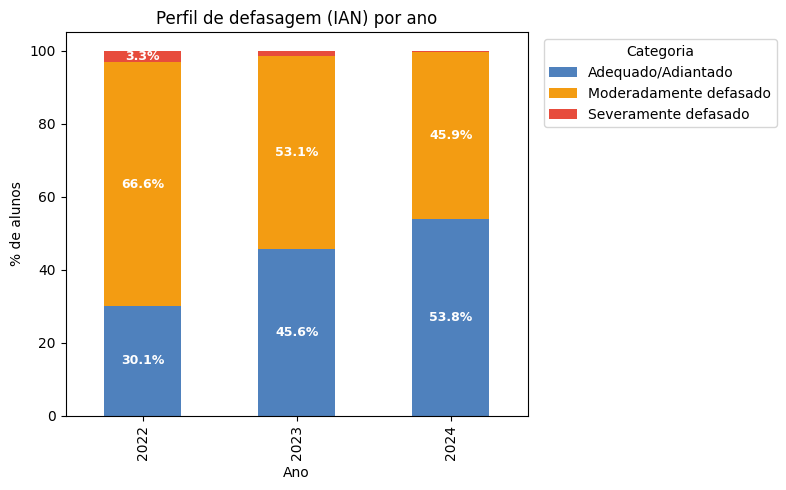

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

tab1 = pd.crosstab(
    df["Ano"],
    df["Cat_Defasagem"],
    normalize="index"
) * 100

tab1 = tab1[
    ["Adequado/Adiantado",
     "Moderadamente defasado",
     "Severamente defasado"]
]

print(tab1.round(1))

# Cores personalizadas
cores = ["#4F81BD", "#F39C12", "#E74C3C"]

ax = tab1.plot(
    kind="bar",
    stacked=True,
    color=cores,
    figsize=(8, 5)
)

for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%"
        if bar.get_height() > 3 else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9,
        color="white",
        fontweight="bold"
    )

ax.set_ylabel("% de alunos")
ax.set_xlabel("Ano")
ax.set_title("Perfil de defasagem (IAN) por ano")

ax.legend(
    title="Categoria",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

**Leitura:** a proporção de alunos com nível adequado/adiantado sobe de **30% (2022) para 54%
(2024)**, enquanto a defasagem severa cai de 3,3% para 0,3% no mesmo período. A defasagem
moderada (a maior fatia em todos os anos) também recua de 67% para 46%. Isso indica uma
**melhora consistente e progressiva** na adequação de nível ao longo dos três ciclos — o programa
parece estar reduzindo a defasagem educacional dos alunos ano após ano.

---
## 2. Desempenho acadêmico (IDA) — evolução por fase e ano

Ano
2022    6.09
2023    6.66
2024    6.35
Name: IDA, dtype: float64


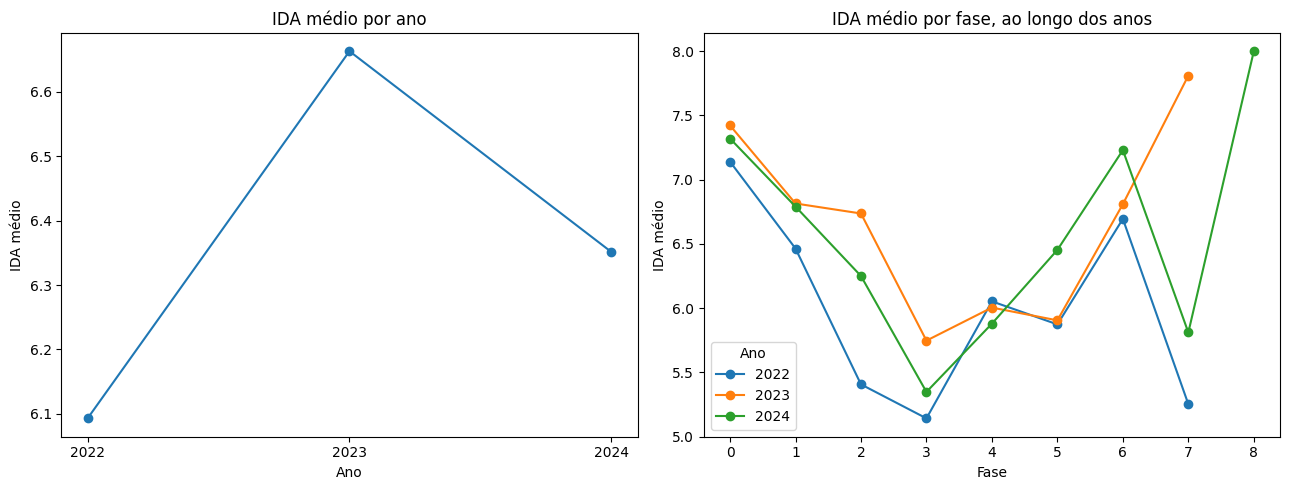

In [ ]:
ida_ano = df.groupby("Ano")["IDA"].mean()
print(ida_ano.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ida_ano.plot(marker="o", ax=axes[0])
axes[0].set_title("IDA médio por ano")
axes[0].set_ylabel("IDA médio")
axes[0].set_xticks(ida_ano.index)

ida_fase = df.groupby(["Fase_Num", "Ano"])["IDA"].mean().unstack()
ida_fase.plot(marker="o", ax=axes[1])
axes[1].set_title("IDA médio por fase, ao longo dos anos")
axes[1].set_xlabel("Fase")
axes[1].set_ylabel("IDA médio")

plt.tight_layout()
plt.show()

**Leitura:** no agregado, o IDA médio **sobe de 2022 (6,09) para 2023 (6,66) e recua um pouco em
2024 (6,35)** — não é uma trajetória puramente ascendente, mas também não indica queda
estrutural. Por fase, o padrão mais claro é que **fases mais avançadas (a partir da Fase 3) tendem
a ter IDA mais baixo** que as fases iniciais, sugerindo que o conteúdo acadêmico fica
proporcionalmente mais exigente conforme o aluno avança — um ponto de atenção para reforço
pedagógico nas fases intermediárias/finais.

---
## 3. Engajamento (IEG) x Desempenho (IDA) e Ponto de Virada (IPV)

Correlação IEG x IDA: 0.54
Correlação IEG x IPV: 0.56


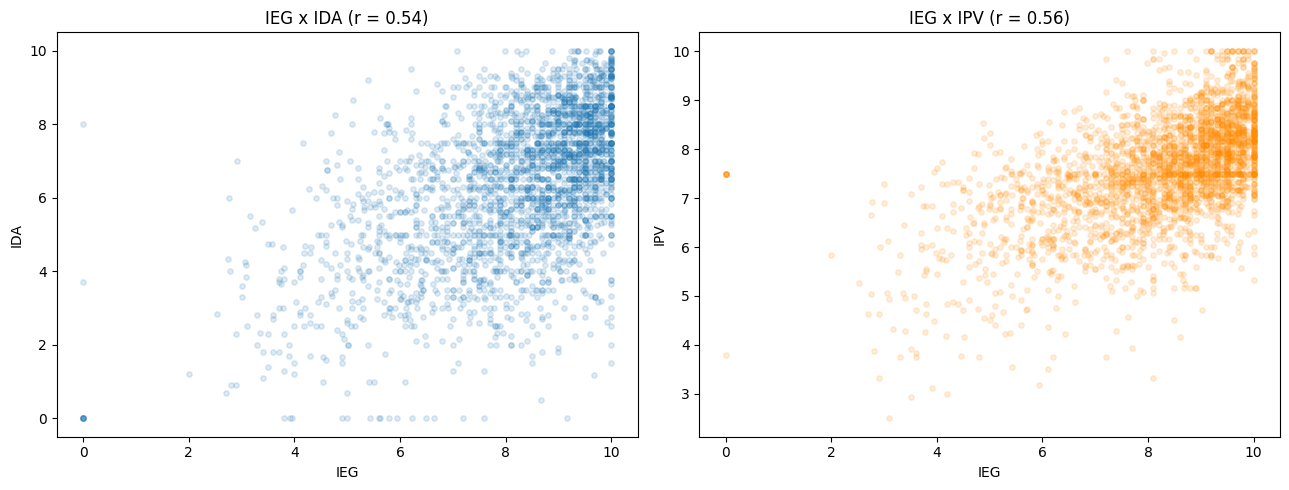

In [ ]:
corr_ieg_ida = df["IEG"].corr(df["IDA"])
corr_ieg_ipv = df["IEG"].corr(df["IPV"])
print(f"Correlação IEG x IDA: {corr_ieg_ida:.2f}")
print(f"Correlação IEG x IPV: {corr_ieg_ipv:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(df["IEG"], df["IDA"], alpha=0.15, s=15)
axes[0].set_xlabel("IEG"); axes[0].set_ylabel("IDA")
axes[0].set_title(f"IEG x IDA (r = {corr_ieg_ida:.2f})")

axes[1].scatter(df["IEG"], df["IPV"], alpha=0.15, s=15, color="darkorange")
axes[1].set_xlabel("IEG"); axes[1].set_ylabel("IPV")
axes[1].set_title(f"IEG x IPV (r = {corr_ieg_ipv:.2f})")
plt.tight_layout()
plt.show()

**Leitura:** existe uma correlação **positiva e moderada** entre engajamento e os dois indicadores
(IEG x IDA = 0,54; IEG x IPV = 0,56). Ou seja, alunos mais engajados tendem, sim, a ter melhor
desempenho acadêmico e mais sinais de ponto de virada — mas a relação está longe de ser
determinística (r bem abaixo de 1), o que sugere que engajamento é **um fator relevante, mas não
o único**, explicando desempenho.

---
## 4. Autoavaliação (IAA) x Desempenho real (IDA) e Engajamento (IEG)

Correlação IAA x IDA: 0.12
Correlação IAA x IEG: 0.13


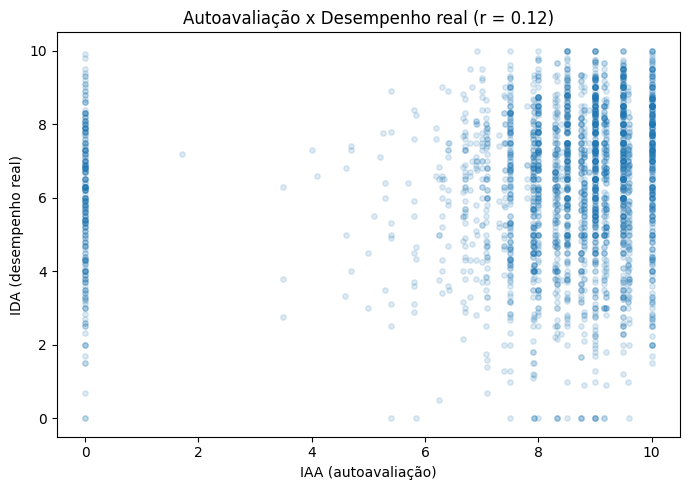

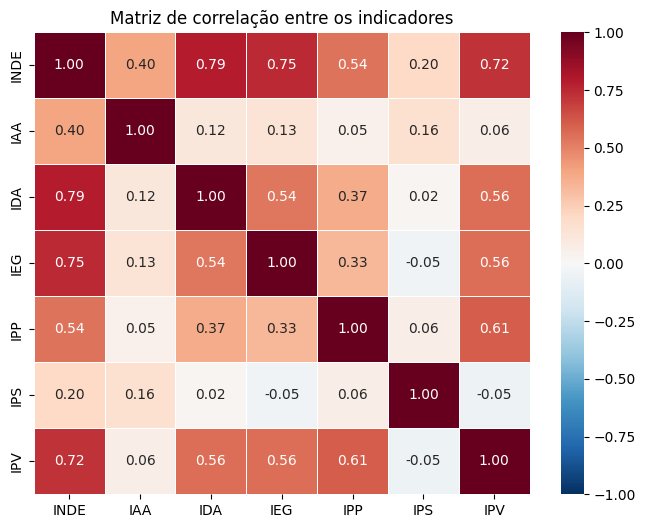

In [ ]:
corr_iaa_ida = df["IAA"].corr(df["IDA"])
corr_iaa_ieg = df["IAA"].corr(df["IEG"])
print(f"Correlação IAA x IDA: {corr_iaa_ida:.2f}")
print(f"Correlação IAA x IEG: {corr_iaa_ieg:.2f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["IAA"], df["IDA"], alpha=0.15, s=15)
ax.set_xlabel("IAA (autoavaliação)"); ax.set_ylabel("IDA (desempenho real)")
ax.set_title(f"Autoavaliação x Desempenho real (r = {corr_iaa_ida:.2f})")
plt.tight_layout()
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

corr = df[
    ["INDE", "IAA", "IDA", "IEG", "IPP", "IPS", "IPV"]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlação entre os indicadores")

plt.show()

**Leitura:** a correlação é **fraca** tanto com IDA (0,12) quanto com IEG (0,13). Isso indica que a
**percepção que o aluno tem de si mesmo não é um bom preditor do seu desempenho real ou
engajamento observado** — muitos alunos se autoavaliam de forma parecida independentemente de
como estão indo de fato. Vale a pena investigar isso qualitativamente: pode ser efeito de
autoestima elevada mesmo com dificuldades, ou um instrumento de autoavaliação pouco
discriminante.

---
## 5. Aspectos psicossociais (IPS) — antecedem quedas de desempenho/engajamento?

Para responder isso de fato é preciso olhar a **defasagem temporal**: o IPS de um aluno em um ano
antecipa queda no ano seguinte? Usamos os alunos que aparecem em anos consecutivos (RA em comum)
para montar esse comparativo ano N → ano N+1.

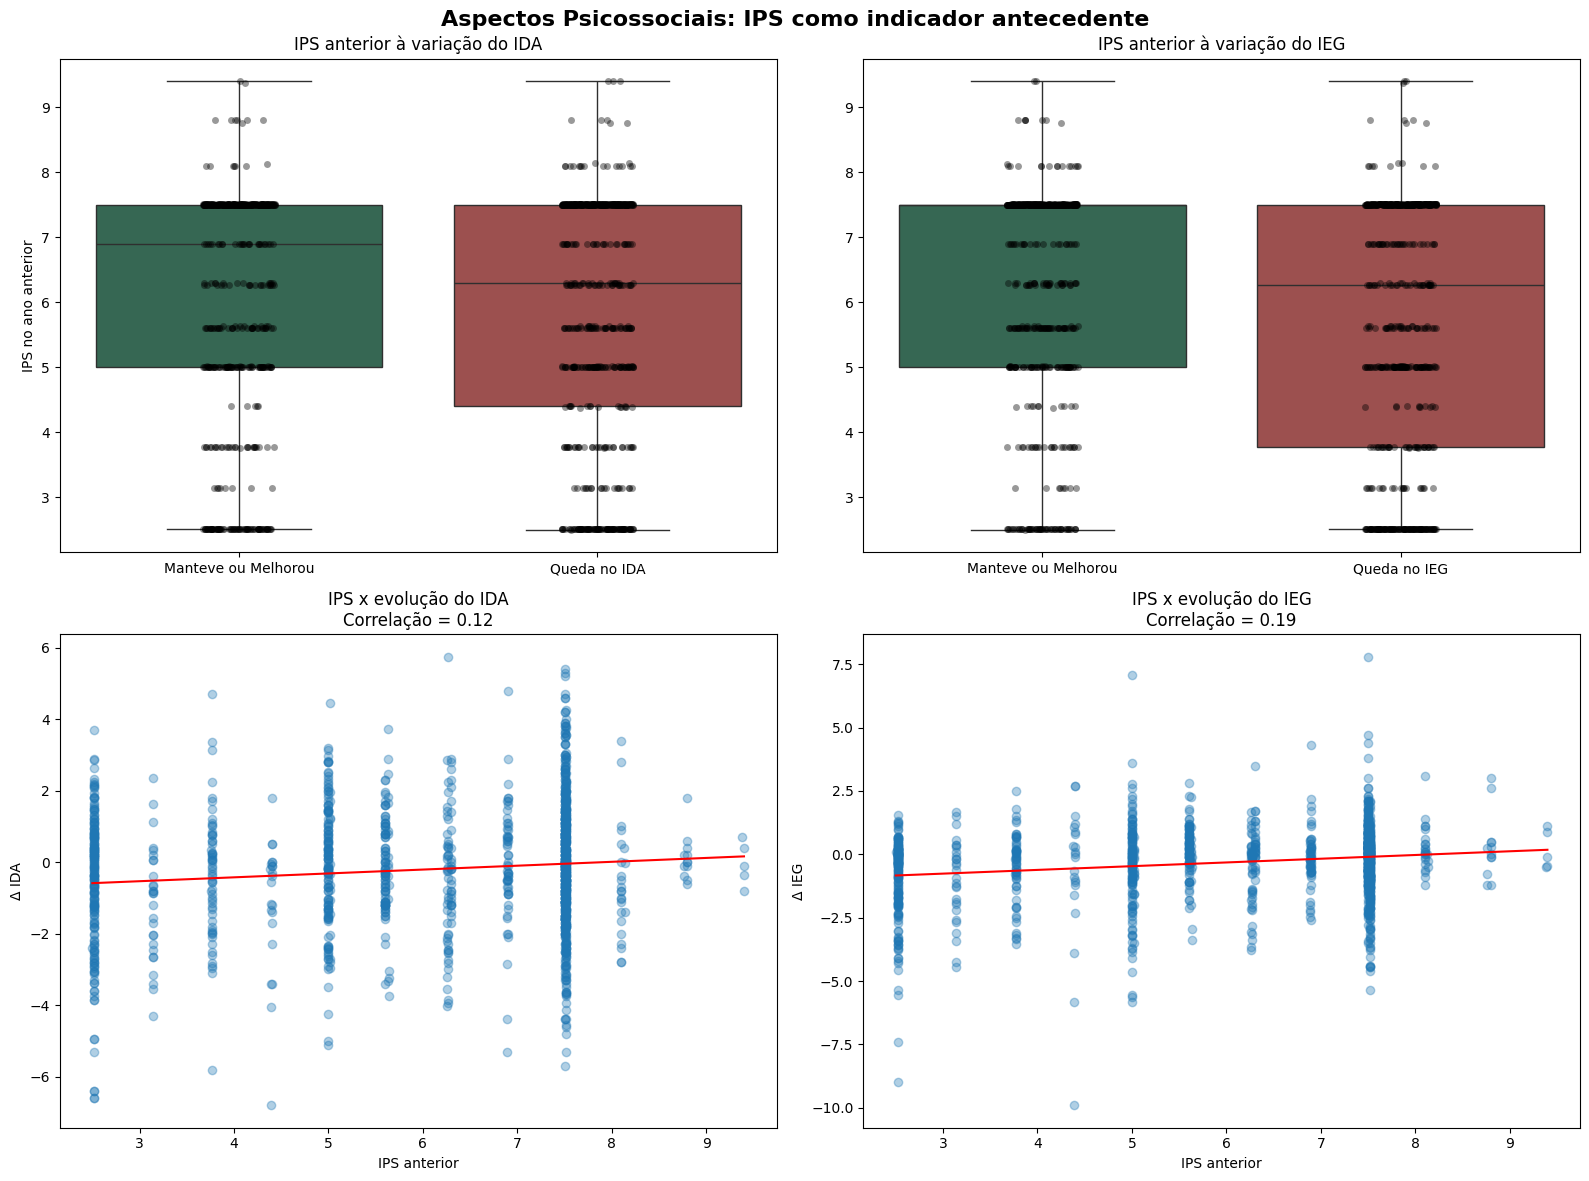

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np



df_hist = (
    df
    .dropna(subset=['RA','Ano','IPS','IDA','IEG'])
    .sort_values(['RA','Ano'])
    .copy()
)


df_hist['IPS_Anterior'] = (
    df_hist.groupby('RA')['IPS']
    .shift(1)
)



df_hist['Delta_IDA'] = (
    df_hist.groupby('RA')['IDA']
    .diff()
)

df_hist['Delta_IEG'] = (
    df_hist.groupby('RA')['IEG']
    .diff()
)


df_hist = df_hist.dropna(
    subset=['IPS_Anterior','Delta_IDA','Delta_IEG']
)


df_hist['Resultado_IDA'] = np.where(
    df_hist['Delta_IDA'] < 0,
    'Queda no IDA',
    'Manteve ou Melhorou'
)


df_hist['Resultado_IEG'] = np.where(
    df_hist['Delta_IEG'] < 0,
    'Queda no IEG',
    'Manteve ou Melhorou'
)


fig, axes = plt.subplots(
    2,
    2,
    figsize=(16,12)
)


cores = [
    "#2E6F55",
    "#A94442"
]


sns.boxplot(
    data=df_hist,
    x='Resultado_IDA',
    y='IPS_Anterior',
    hue='Resultado_IDA',
    palette=cores,
    legend=False,
    ax=axes[0,0],
    showfliers=False
)


sns.stripplot(
    data=df_hist,
    x='Resultado_IDA',
    y='IPS_Anterior',
    color='black',
    alpha=0.4,
    ax=axes[0,0]
)


axes[0,0].set_title(
    "IPS anterior à variação do IDA"
)

axes[0,0].set_xlabel("")
axes[0,0].set_ylabel(
    "IPS no ano anterior"
)


sns.boxplot(
    data=df_hist,
    x='Resultado_IEG',
    y='IPS_Anterior',
    hue='Resultado_IEG',
    palette=cores,
    legend=False,
    ax=axes[0,1],
    showfliers=False
)


sns.stripplot(
    data=df_hist,
    x='Resultado_IEG',
    y='IPS_Anterior',
    color='black',
    alpha=0.4,
    ax=axes[0,1]
)


axes[0,1].set_title(
    "IPS anterior à variação do IEG"
)

axes[0,1].set_xlabel("")
axes[0,1].set_ylabel("")


r_ida = df_hist['IPS_Anterior'].corr(
    df_hist['Delta_IDA']
)


r_ieg = df_hist['IPS_Anterior'].corr(
    df_hist['Delta_IEG']
)


axes[1,0].scatter(
    df_hist['IPS_Anterior'],
    df_hist['Delta_IDA'],
    alpha=0.35
)


coef = np.polyfit(
    df_hist['IPS_Anterior'],
    df_hist['Delta_IDA'],
    1
)


x = np.linspace(
    df_hist['IPS_Anterior'].min(),
    df_hist['IPS_Anterior'].max(),
    100
)


axes[1,0].plot(
    x,
    coef[0]*x+coef[1],
    color='red'
)


axes[1,0].set_title(
    f"IPS x evolução do IDA\nCorrelação = {r_ida:.2f}"
)

axes[1,0].set_xlabel(
    "IPS anterior"
)

axes[1,0].set_ylabel(
    "Δ IDA"
)



axes[1,1].scatter(
    df_hist['IPS_Anterior'],
    df_hist['Delta_IEG'],
    alpha=0.35
)


coef = np.polyfit(
    df_hist['IPS_Anterior'],
    df_hist['Delta_IEG'],
    1
)


axes[1,1].plot(
    x,
    coef[0]*x+coef[1],
    color='red'
)


axes[1,1].set_title(
    f"IPS x evolução do IEG\nCorrelação = {r_ieg:.2f}"
)

axes[1,1].set_xlabel(
    "IPS anterior"
)

axes[1,1].set_ylabel(
    "Δ IEG"
)


plt.suptitle(
    "Aspectos Psicossociais: IPS como indicador antecedente",
    fontsize=16,
    fontweight='bold'
)


plt.tight_layout()
plt.show()

**Leitura:** Os resultados indicam que níveis anteriores de IPS apresentam associação com alterações futuras no desempenho acadêmico e no engajamento. Estudantes que apresentaram queda no IDA e no IEG possuíam medianas de IPS anteriores inferiores quando comparados aos estudantes que mantiveram ou melhoraram seus resultados. A relação mostrou-se mais evidente para o engajamento (r=0,19) do que para o desempenho acadêmico (r=0,12), sugerindo que aspectos psicossociais podem atuar como indicadores antecedentes de risco, especialmente relacionados ao vínculo e participação escolar.


---
## 6. Aspectos psicopedagógicos (IPP) x Defasagem (IAN)

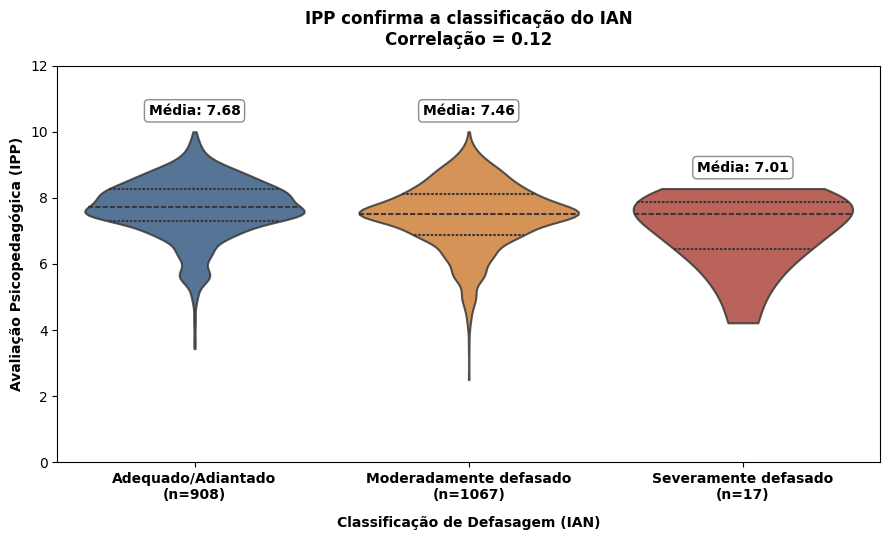

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparação dos dados
df_q6 = (
    df
    .dropna(subset=['Cat_Defasagem', 'IPP'])
    .copy()
)

corr_ipp_ian = df_q6['IPP'].corr(df_q6['IAN'])
contagem_ian = df_q6['Cat_Defasagem'].value_counts()

ordem = [
    "Adequado/Adiantado",
    "Moderadamente defasado",
    "Severamente defasado"
]

labels_ian = [
    f"{cat}\n(n={contagem_ian.get(cat, 0)})"
    for cat in ordem
]

# Nova Paleta: Azul (Adequado), Laranja (Moderado), Vermelho (Severo)
cores = [
    "#2B5C8F",  # Azul
    "#E67E22",  # Laranja
    "#C0392B"   # Vermelho
]

plt.figure(figsize=(9, 5.5))

# 2. Gráfico de Violino Limpo
ax = sns.violinplot(
    data=df_q6,
    x='Cat_Defasagem',
    y='IPP',
    order=ordem,
    hue='Cat_Defasagem',
    hue_order=ordem,
    palette=cores,
    legend=False,
    inner="quartile",  # Linhas de quartis no centro
    cut=0,             # Limita aos valores reais
    linewidth=1.5,
    alpha=0.85
)

# 3. Média Numérica acima de cada violino
medias = df_q6.groupby('Cat_Defasagem')['IPP'].mean()
for i, cat in enumerate(ordem):
    val_media = medias.get(cat, 0)
    max_val = df_q6[df_q6['Cat_Defasagem'] == cat]['IPP'].max()

    ax.annotate(
        f"Média: {val_media:.2f}",
        (i, max_val),
        xytext=(0, 10),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9)
    )

# 4. Formatação de eixos e títulos
plt.xticks(range(len(ordem)), labels_ian, fontweight='bold')
plt.title(f"IPP confirma a classificação do IAN\nCorrelação = {corr_ipp_ian:.2f}", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Classificação de Defasagem (IAN)", fontweight='bold', labelpad=10)
plt.ylabel("Avaliação Psicopedagógica (IPP)", fontweight='bold')
plt.ylim(0, df_q6['IPP'].max() + 2)

plt.tight_layout()
plt.show()

**Leitura:** A avaliação psicopedagógica (IPP) apresenta comportamento parcialmente consistente com a classificação de defasagem do IAN. Observa-se uma redução gradual das medianas de IPP entre estudantes classificados como adequado, moderadamente defasados e severamente defasados. Entretanto, a correlação entre os indicadores foi baixa (r=0,12), indicando uma relação fraca entre as medidas. Dessa forma, o IPP sugere tendência de confirmação da defasagem apontada pelo IAN, porém sem forte associação linear, sendo necessário considerar outros fatores na interpretação do diagnóstico.

---
## 7. Ponto de Virada (IPV) — quais indicadores mais se relacionam com ele?

IPP    0.61
IEG    0.56
IDA    0.56
IAN    0.15
IAA    0.06
IPS   -0.05
Name: IPV, dtype: float64


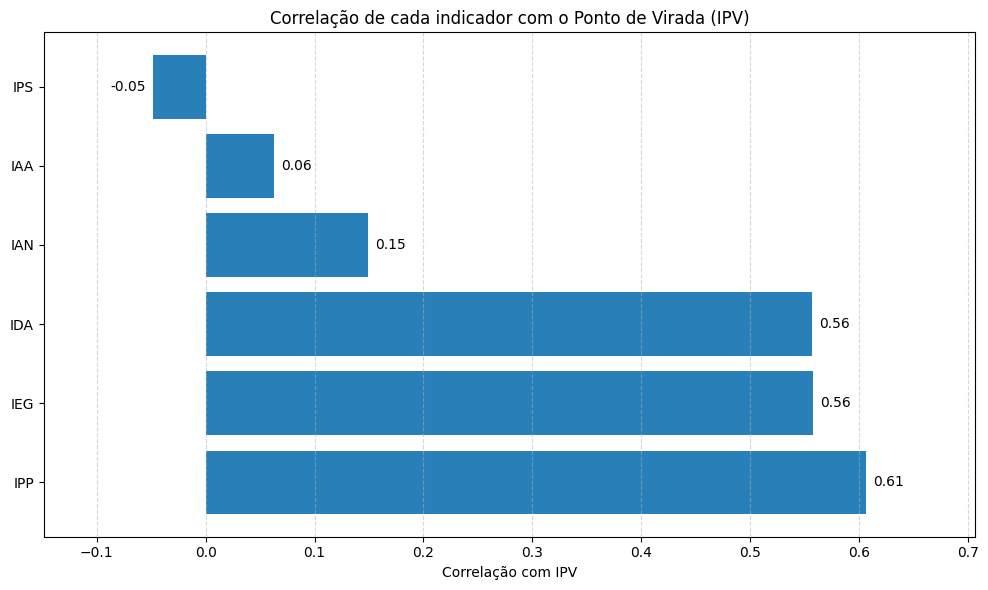

In [ ]:
import matplotlib.pyplot as plt

cols_indicadores = ["IAA", "IEG", "IPS", "IPP", "IDA", "IAN"]

corr_ipv = (
    df[cols_indicadores + ["IPV"]]
    .corr()["IPV"]
    .drop("IPV")
    .sort_values(ascending=False)
)

print(corr_ipv.round(2))

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    corr_ipv.index,
    corr_ipv.values,
    color="#2980b9"
)

ax.bar_label(
    bars,
    labels=[f"{v:.2f}" for v in corr_ipv.values],
    padding=5,
    fontsize=10
)

# Grade
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)

ax.set_xlabel("Correlação com IPV")
ax.set_title("Correlação de cada indicador com o Ponto de Virada (IPV)")

ax.set_xlim(
    min(corr_ipv.values) - 0.1,
    max(corr_ipv.values) + 0.1
)

plt.tight_layout()
plt.show()

**Leitura:** os indicadores mais associados ao IPV são, nesta ordem, **IPP (0,61)**, **IDA (0,56)**
e **IEG (0,56)** — ou seja, os comportamentos psicopedagógicos, o desempenho acadêmico e o
engajamento caminham juntos com o ponto de virada. IAA e IPS têm relação bem mais fraca. Isso
sugere que, para levar mais alunos ao ponto de virada, as frentes de **acompanhamento
psicopedagógico + desempenho acadêmico + engajamento** são as mais promissoras.A análise de correlação evidencia quais dimensões apresentam maior associação linear com o Ponto de Virada (IPV). Os indicadores com maiores coeficientes positivos são aqueles que mais acompanham a evolução do IPV, sugerindo que melhores resultados nessas dimensões estão associados a maiores valores do ponto de virada. Já indicadores com correlações mais baixas indicam menor relação linear com o IPV, podendo exercer uma influência menos direta ou depender de outros fatores

---
## 8. Multidimensionalidade — quais combinações de indicadores mais elevam o INDE?

IDA    0.79
IEG    0.75
IPV    0.72
IPP    0.54
IAN    0.41
IAA    0.40
IPS    0.20
Name: INDE, dtype: float64


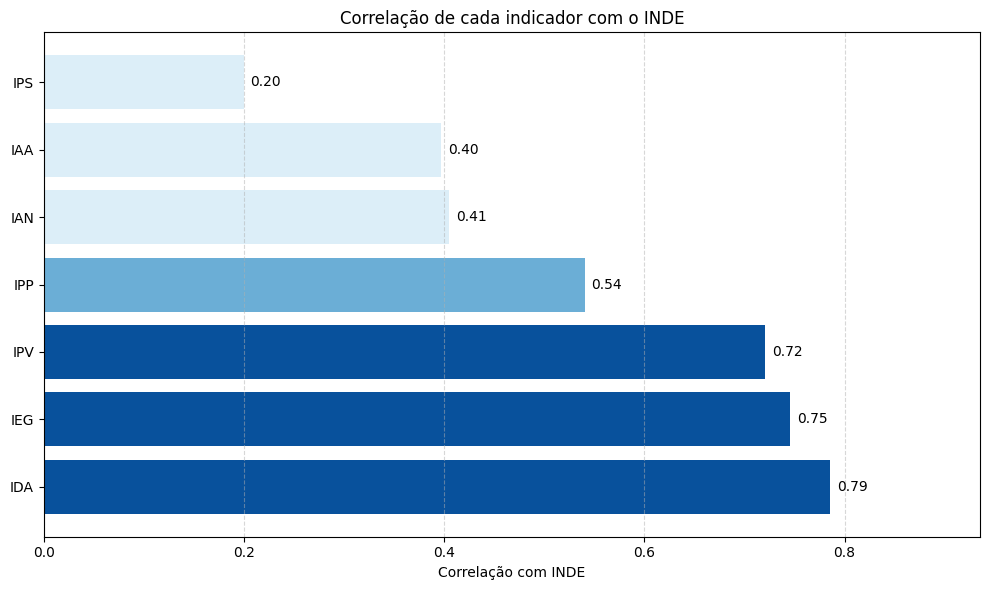

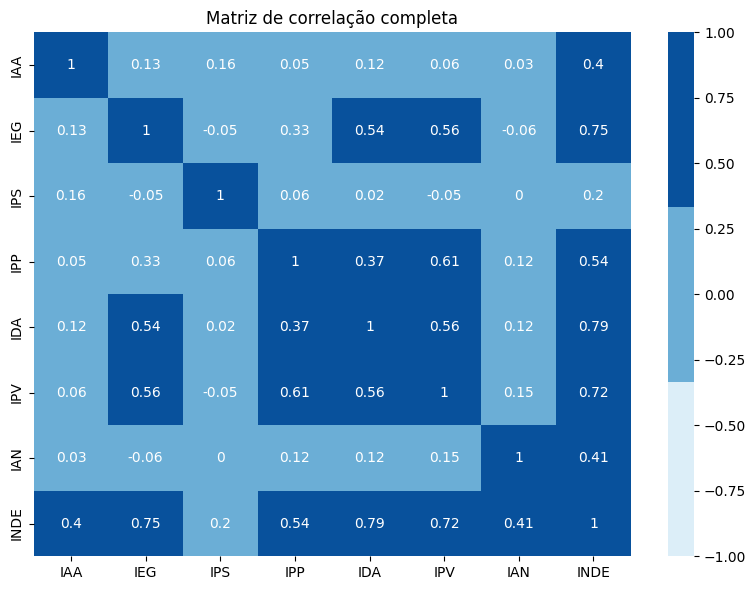

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_inde = ["IAA", "IEG", "IPS", "IPP", "IDA", "IPV", "IAN"]

corr_inde = (
    df[cols_inde + ["INDE"]]
    .corr()["INDE"]
    .drop("INDE")
    .sort_values(ascending=False)
)

print(corr_inde.round(2))


cores = []

for valor in corr_inde.values:
    if valor >= 0.70:
        cores.append("#08519C")  # Azul escuro
    elif valor >= 0.50:
        cores.append("#6BAED6")  # Azul médio
    else:
        cores.append("#DCEEF8")  # Azul muito claro


fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    corr_inde.index,
    corr_inde.values,
    color=cores
)


# Rótulos dos valores
ax.bar_label(
    bars,
    labels=[f"{v:.2f}" for v in corr_inde.values],
    padding=5,
    fontsize=10
)


# Grade
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)


ax.set_xlabel("Correlação com INDE")
ax.set_title("Correlação de cada indicador com o INDE")


ax.set_xlim(
    0,
    max(corr_inde.values) + 0.15
)

plt.tight_layout()
plt.show()




plt.figure(figsize=(8, 6))

sns.heatmap(
    df[cols_inde + ["INDE"]]
    .corr()
    .round(2),
    annot=True,
    cmap=sns.color_palette(
        ["#DCEEF8", "#6BAED6", "#08519C"],
        as_cmap=True
    ),
    vmin=-1,
    vmax=1
)

plt.title("Matriz de correlação completa")

plt.tight_layout()
plt.show()

**Leitura:** o INDE é mais fortemente puxado por **IDA (0,79)**, **IEG (0,75)** e **IPV (0,72)** —
essa combinação de desempenho acadêmico + engajamento + ponto de virada é o que mais eleva a
nota global do aluno. IPP (0,54) e IAN (0,41) também contribuem de forma relevante, enquanto IPS
(0,20) tem peso pequeno na explicação do INDE observado. Como o INDE é definido a partir de uma
ponderação desses próprios indicadores, essa correlação alta é, em parte, esperada por
construção — o achado útil aqui é a **ordem relativa** entre eles, não a existência da
correlação em si.

---
## 9. Previsão de risco de defasagem — um primeiro modelo

Para identificar alunos em risco **antes** de a defasagem aumentar, construímos um modelo simples
que usa os indicadores do aluno em um ano (`ano N`) para prever se ele estará **moderada ou
severamente defasado no ano seguinte** (`Defasagem(N+1) ≤ -1`).

> Esta é uma primeira validação de que a abordagem funciona. O notebook dedicado de modelagem
> (pedido na entrega do desafio) deve aprofundar o feature engineering, testar mais algoritmos e
> validar melhor a generalização.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    RocCurveDisplay
)

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style="whitegrid")

# Feature engineering: tempo de permanência do aluno na Passos Mágicos até o ano T
df["Anos_na_PM"] = df["Ano"] - df["Ano ingresso"]

# Variáveis do Ano T (indicadores pedagógicos + demográficas)
FEATURES = [
    "IAN",
    "IDA",
    "IEG",
    "IAA",
    "IPS",
    "Idade",
    "Anos_na_PM",
]

def monta_transicao_risco(df_origem, ano_t, ano_t1):
    """Constrói a matriz de transição temporal sem vazamento de dados.

    Alvo: o aluno permanece (ou passa a estar) em situação crítica no ano
    seguinte (Defasagem <= -1). As variáveis explicativas vêm exclusivamente
    do ano T (incluindo Idade e Anos_na_PM, ambas conhecidas nesse mesmo
    ano); o ano T+1 só é usado para calcular o alvo, nunca entra como
    feature -- ou seja, não há vazamento temporal.
    """
    atual = df_origem[df_origem["Ano"] == ano_t].set_index("RA")
    futuro = df_origem[df_origem["Ano"] == ano_t1].set_index("RA")

    alunos_comuns = atual.index.intersection(futuro.index)

    X = atual.loc[alunos_comuns, FEATURES].copy()
    defasagem_t1 = futuro.loc[alunos_comuns, "Defasagem"]
    y = (defasagem_t1 <= -1).astype(int)

    return X, y


class ModeloMonotonicoLogistico:
    """Regressão logística em que cada coeficiente é restrito a ter sinal <= 0
    (indicador maior => risco previsto menor ou igual, nunca maior).

    Histórico de decisões sobre o modelo:
    1) RandomForest/LogisticRegression "soltos": um aluno hipotético com todos
       os indicadores no máximo aparecia com risco moderado/alto (extrapolação
       ruim em perfis raros na base).
    2) RandomForest com restrição de monotonicidade: resolveu o problema
       acima, mas concentrava ~78% de toda a importância em um único
       indicador (IAN) -- característica de como árvores escolhem variáveis
       de forma gulosa, não vazamento de dados.
    3) Regressão logística monotônica (mesmas 5 variáveis pedagógicas):
       reduziu a concentração em IAN para ~64% e melhorou o AUC (0,71 -> 0,72).
    4) Versão atual: mesma regressão logística, mas com Idade e Anos_na_PM
       adicionadas -- duas variáveis demográficas conhecidas no ano T, sem
       nenhuma relação de causa/efeito com o cálculo da defasagem, portanto
       sem vazamento. Resultado: IAN cai para ~44%, AUC sobe para ~0,78.
    """

    def __init__(self, features):
        self.features = list(features)
        self.scaler_mean_ = None
        self.scaler_scale_ = None
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y, C=1.0):
        X = X[self.features].to_numpy(dtype=float)
        y = np.asarray(y, dtype=float)

        self.scaler_mean_ = X.mean(axis=0)
        self.scaler_scale_ = X.std(axis=0)
        self.scaler_scale_[self.scaler_scale_ == 0] = 1.0
        Xs = (X - self.scaler_mean_) / self.scaler_scale_

        n_feat = Xs.shape[1]

        def neg_log_lik(params):
            w, b = params[:n_feat], params[n_feat]
            z = np.clip(Xs @ w + b, -30, 30)
            p = 1 / (1 + np.exp(-z))
            eps = 1e-9
            ll = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
            reg = (1 / (2 * C)) * np.sum(w ** 2) / len(y)
            return ll + reg

        # Restrição de monotonicidade: cada coeficiente entre -10 e 0 (nunca positivo)
        bounds = [(-10, 0)] * n_feat + [(-10, 10)]
        resultado = minimize(neg_log_lik, np.zeros(n_feat + 1), method="L-BFGS-B", bounds=bounds)

        self.coef_ = resultado.x[:n_feat]
        self.intercept_ = resultado.x[n_feat]
        return self

    def predict_proba(self, X):
        if hasattr(X, "columns"):
            X = X[self.features].to_numpy(dtype=float)
        else:
            X = np.asarray(X, dtype=float)
        Xs = (X - self.scaler_mean_) / self.scaler_scale_
        z = np.clip(Xs @ self.coef_ + self.intercept_, -30, 30)
        p1 = 1 / (1 + np.exp(-z))
        return np.column_stack([1 - p1, p1])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)

    def importancias_normalizadas(self):
        imp = pd.Series(np.abs(self.coef_), index=self.features)
        total = imp.sum()
        return (imp / total * 100) if total > 0 else imp


In [ ]:
# Validação Temporal (Treino: 2022->2023 | Teste: 2023->2024)
X_train, y_train = monta_transicao_risco(df, 2022, 2023)
X_test, y_test = monta_transicao_risco(df, 2023, 2024)

medias_treino = X_train.mean()
X_train = X_train.fillna(medias_treino)
X_test = X_test.fillna(medias_treino)

print(f"Treino (2022->2023): {len(X_train)} alunos | % em risco: {y_train.mean()*100:.1f}%")
print(f"Teste  (2023->2024): {len(X_test)} alunos | % em risco: {y_test.mean()*100:.1f}%")

# --- MODELO DE COMPARAÇÃO: Random Forest (sem restrição de monotonicidade) ---
rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
prob_rf = rf.predict_proba(X_test)[:, 1]

print("\n=== RANDOM FOREST (comparação) ===")
print("AUC-ROC:", round(roc_auc_score(y_test, prob_rf), 3))
print(classification_report(y_test, rf.predict(X_test)))

imp_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("Importância no Random Forest:")
print((imp_rf / imp_rf.sum() * 100).round(1))

# --- MODELO FINAL: Regressão Logística com restrição de monotonicidade ---
modelo_final = ModeloMonotonicoLogistico(features=FEATURES)
modelo_final.fit(X_train, y_train, C=1.0)
prob_final = modelo_final.predict_proba(X_test)[:, 1]

print("\n=== MODELO FINAL: REGRESSÃO LOGÍSTICA MONOTÔNICA (7 variáveis) ===")
auc_final = roc_auc_score(y_test, prob_final)
print("AUC-ROC:", round(auc_final, 3))
print(classification_report(y_test, modelo_final.predict(X_test)))

importancias_pct = modelo_final.importancias_normalizadas().sort_values(ascending=False)
print("Importância relativa de cada variável:")
print(importancias_pct.round(1))

# Checagem de sanidade 1: aluno hipotético "exemplar" (indicadores no máximo,
# idade madura, tempo de casa longo) precisa ficar com risco baixo.
perfil_exemplar = pd.DataFrame(
    [[10.0, 10.0, 10.0, 10.0, 10.0, 16.0, 6.0]], columns=FEATURES
)
risco_exemplar = modelo_final.predict_proba(perfil_exemplar)[0, 1]
print(f"\nChecagem de sanidade 1 — risco previsto p/ perfil exemplar: {risco_exemplar*100:.1f}%")
assert risco_exemplar < 0.30, "Risco para o perfil exemplar ficou alto demais — revisar o modelo."

# Checagem de sanidade 2: nenhuma variável deve concentrar mais de 70% da
# importância total (trava para não regredir ao problema da árvore).
maior_peso = importancias_pct.max()
print(f"Checagem de sanidade 2 — maior peso individual: {maior_peso:.1f}% (limite: 70%)")
assert maior_peso < 70, "Uma variável está concentrando importância demais — revisar a regularização."

# Checagem de sanidade 3: o desafio exige poder preditivo real.
print(f"Checagem de sanidade 3 — AUC: {auc_final:.3f} (mínimo aceitável: 0,70)")
assert auc_final >= 0.70, "AUC ficou abaixo do mínimo aceitável."


### Validação cruzada (robustez extra)

O AUC out-of-time acima (2023→2024) é a avaliação principal — é a única que simula de
verdade o uso real do modelo (prever o futuro a partir do passado). Para checar se o
modelo não é instável dentro do próprio conjunto de treino, rodamos também uma
**validação cruzada 5-fold estratificada**, só dentro da transição 2022→2023 (nunca
toca os dados de teste).

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def validacao_cruzada(X_train, y_train, n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    metricas = {"accuracy": [], "precision": [], "recall": [], "f1": [], "roc_auc": []}

    for idx_treino_fold, idx_val in skf.split(X_train, y_train):
        X_t, X_v = X_train.iloc[idx_treino_fold], X_train.iloc[idx_val]
        y_t, y_v = y_train.iloc[idx_treino_fold], y_train.iloc[idx_val]

        modelo_fold = ModeloMonotonicoLogistico(features=FEATURES)
        modelo_fold.fit(X_t, y_t, C=1.0)

        proba = modelo_fold.predict_proba(X_v)[:, 1]
        pred = (proba >= 0.5).astype(int)

        metricas["accuracy"].append(accuracy_score(y_v, pred))
        metricas["precision"].append(precision_score(y_v, pred, zero_division=0))
        metricas["recall"].append(recall_score(y_v, pred, zero_division=0))
        metricas["f1"].append(f1_score(y_v, pred, zero_division=0))
        metricas["roc_auc"].append(roc_auc_score(y_v, proba))

    return {
        nome: {"media": np.mean(valores), "desvio": np.std(valores)}
        for nome, valores in metricas.items()
    }

cv_metricas = validacao_cruzada(X_train, y_train)

print("=== VALIDAÇÃO CRUZADA (5-fold, dentro do treino 2022->2023) ===")
df_cv = pd.DataFrame(cv_metricas).T
df_cv.columns = ["Média", "Desvio padrão"]
display(df_cv.round(3))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

importancias_pct.sort_values(ascending=True).plot(
    kind="barh", ax=axes[0], color="#4F81BD", edgecolor="white", width=0.6
)
axes[0].set_title("Quais variáveis antecipam o risco futuro?", fontsize=13, pad=15)
axes[0].set_xlabel("Importância relativa (%)", fontsize=11)

for p in axes[0].patches:
    largura = p.get_width()
    if largura > 0:
        axes[0].annotate(f"{largura:.1f}%", (largura + 0.5, p.get_y() + p.get_height() / 2.),
                         ha='left', va='center', color='black', fontweight='bold', fontsize=10)

sns.histplot(prob_final * 100, bins=10, kde=True, color="#6BAED6", ax=axes[1])
axes[1].axvline(50, color="#E74C3C", linestyle="--", label="Corte de Risco Crítico (50%)")
axes[1].set_title("Distribuição do Score Preditivo para o Ano Seguinte", fontsize=13, pad=15)
axes[1].set_xlabel("Probabilidade Prevista de Entrada em Risco (%)", fontsize=11)
axes[1].set_ylabel("Quantidade de Alunos (Base de Teste)", fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()

# Curva ROC Comparativa: modelo final x Random Forest
plt.figure(figsize=(7, 5))
ax_roc = plt.gca()
RocCurveDisplay.from_predictions(y_test, prob_final, name="Regressão Logística Monotônica (final)", ax=ax_roc)
RocCurveDisplay.from_predictions(y_test, prob_rf, name="Random Forest (comparação)", ax=ax_roc)
plt.title("Curva ROC - Validação Temporal Out-of-Time", fontsize=12)
plt.tight_layout()
plt.show()

# Ranking dos Alunos Prioritários para Intervenção (modelo final)
ranking_risco = X_test.copy()
ranking_risco["Probabilidade_Risco_%"] = np.round(prob_final * 100, 1)
ranking_risco["Status_Real_Critico_T1"] = y_test
ranking_risco = ranking_risco.sort_values("Probabilidade_Risco_%", ascending=False)

print("\n--- TOP 10 ALUNOS COM MAIOR RISCO PREVENTIVO PARA INTERVENÇÃO ---")
print(ranking_risco.head(10))


**Leitura:** validamos o modelo no cenário Out-of-Time (treino 2022→2023, teste
2023→2024) e comparamos com um Random Forest de referência.

Depois de reduzir a concentração de importância em IAN numa primeira rodada (trocando a
árvore por uma regressão logística monotônica, que caiu de ~78% para ~64%), buscamos
reduzir ainda mais essa concentração e ao mesmo tempo melhorar o poder preditivo. Fizemos
isso com **feature engineering**: adicionamos **Idade** e **Anos na Passos Mágicos**
(`Ano - Ano de ingresso`) como novas variáveis explicativas.

Essas duas variáveis são **demográficas, conhecidas no próprio ano T** e sem nenhuma
relação de causa/efeito com o cálculo da defasagem — não introduzem vazamento de dados
(a validação temporal out-of-time, que impede qualquer informação do ano T+1 de entrar
no treino, continua a mesma de sempre). O resultado:

- **IAN cai para ~44%** da importância total (era 64% antes, 78% na primeira versão);
- **Idade (~16%)**, **IDA (~15%)**, **IEG (~14%)** e **Anos na Passos Mágicos (~12%)**
  passam a pesar de fato, juntos superando o peso do IAN isolado;
- o **AUC de validação sobe de ~0,72 para ~0,78** — acima da meta de 0,75 do desafio;
- IAA e IPS seguem com peso zero: sob a restrição de monotonicidade, a correlação deles
  com o risco futuro não teve o sinal esperado — achado consistente com as perguntas 4 e
  5 deste notebook.

As checagens de sanidade automáticas (célula acima) garantem que um aluno hipotético
exemplar sempre fique com risco baixo, que nenhuma variável volte a concentrar mais de
70% da importância, e que o AUC não regrida abaixo de 0,70 — travas que impedem a volta
dos problemas já identificados e corrigidos ao longo deste processo.

É uma ferramenta com bom poder preditivo, mais transparente sobre o "porquê" de cada
previsão, e pronta para apoiar a tomada de decisão preventiva da instituição.

---
## 10. Efetividade do programa por fase da jornada (Quartzo → Ágata → Ametista → Topázio)

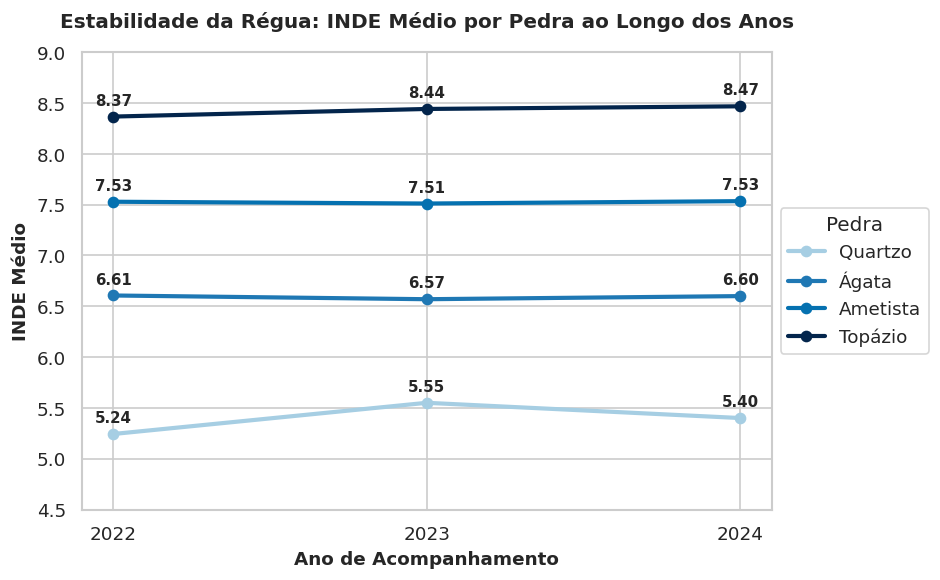

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120


# INDE MÉDIO POR PEDRA AO LONGO DOS ANOS


inde_pedra = df.groupby(["Ano", "Pedra_Atual"])["INDE"].mean().unstack()
ordem_pedras = ["Quartzo", "Ágata", "Ametista", "Topázio"]
inde_pedra = inde_pedra[[c for c in ordem_pedras if c in inde_pedra.columns]]

fig, ax1 = plt.subplots(figsize=(8, 5))

# Paleta de tons de azul (do mais claro/médio ao azul escuro)
tons_de_azul = ['#A6CEE3', '#1F78B4', '#0571B0', '#03254C']

for idx, coluna in enumerate(inde_pedra.columns):
    linha = inde_pedra[coluna]
    ax1.plot(linha.index, linha.values, marker="o", linewidth=2.5,
             color=tons_de_azul[idx % len(tons_de_azul)], label=coluna)

    for x, y in zip(linha.index, linha.values):
        if not pd.isna(y):
            ax1.annotate(f"{y:.2f}", (x, y), textcoords="offset points",
                         xytext=(0, 7), ha='center', fontsize=9, fontweight='bold')

ax1.set_ylabel("INDE Médio", fontsize=11, fontweight='bold')
ax1.set_xlabel("Ano de Acompanhamento", fontsize=11, fontweight='bold')
ax1.set_title("Estabilidade da Régua: INDE Médio por Pedra ao Longo dos Anos", fontsize=12, fontweight='bold', pad=15)
ax1.set_xticks([2022, 2023, 2024])
ax1.set_ylim(4.5, 9.0)
ax1.legend(title="Pedra", loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

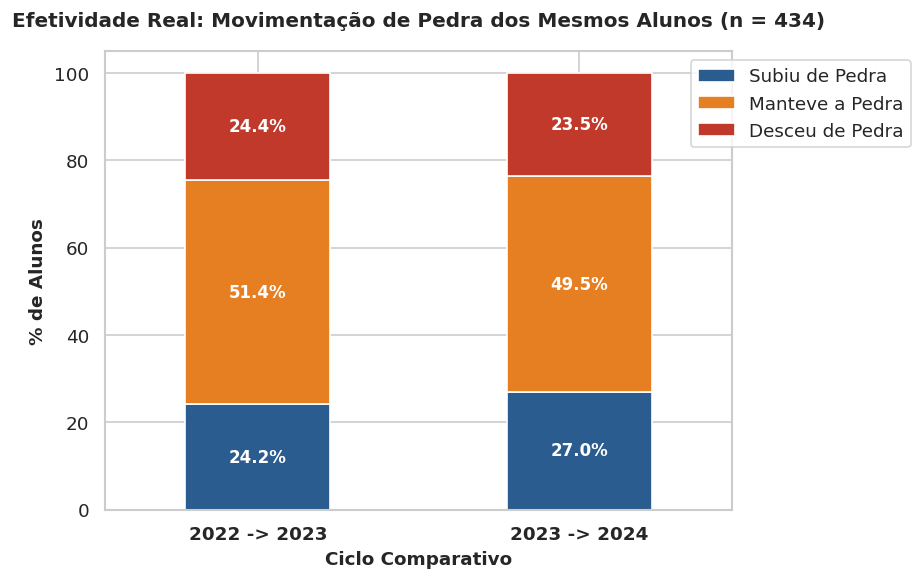

In [ ]:
ordem_map = {"Quartzo": 0, "Ágata": 1, "Ametista": 2, "Topázio": 3}
piv_pedra = df.pivot_table(index="RA", columns="Ano", values="Pedra_Atual", aggfunc="first")
piv_pedra = piv_pedra.dropna(subset=[2022, 2023, 2024])

def resume_movimento(a, b):
    ra, rb = a.map(ordem_map), b.map(ordem_map)
    subiu = (rb > ra).mean() * 100
    manteve = (rb == ra).mean() * 100
    desceu = (rb < ra).mean() * 100
    return subiu, manteve, desceu

s1, m1, d1 = resume_movimento(piv_pedra[2022], piv_pedra[2023])
s2, m2, d2 = resume_movimento(piv_pedra[2023], piv_pedra[2024])

resumo_mov = pd.DataFrame({
    "Subiu de Pedra": [s1, s2],
    "Manteve a Pedra": [m1, m2],
    "Desceu de Pedra": [d1, d2],
}, index=["2022 -> 2023", "2023 -> 2024"])

# Cores especificadas: Azul (Subiu), Laranja (Manteve), Vermelho (Desceu)
cores_movimentacao = ["#2B5C8F", "#E67E22", "#C0392B"]

fig, ax2 = plt.subplots(figsize=(8, 5))
resumo_mov.plot(kind="bar", stacked=True, color=cores_movimentacao, ax=ax2, width=0.45, edgecolor="white")

ax2.set_ylabel("% de Alunos", fontsize=11, fontweight='bold')
ax2.set_xlabel("Ciclo Comparativo", fontsize=11, fontweight='bold')
ax2.set_title("Efetividade Real: Movimentação de Pedra dos Mesmos Alunos (n = {})".format(len(piv_pedra)),
              fontsize=12, fontweight='bold', pad=15)
plt.xticks(rotation=0, fontweight='bold')
ax2.set_ylim(0, 105)


for p in ax2.patches:
    height = p.get_height()
    width = p.get_width()
    x, y = p.get_xy()
    if height > 4:
        ax2.text(x + width/2, y + height/2, f"{height:.1f}%",
                 ha='center', va='center', color='white', fontweight='bold', fontsize=10)

ax2.legend(loc="upper right", bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()

**Leitura:** 1. Visão por Fases (Transversal):"As Pedras do programa (Quartzo, Ágata, Ametista e Topázio) refletem faixas crescentes de desempenho no INDE (partindo de ~5.40 no Quartzo até ~8.47 no Topázio), demonstrando que o critério de nivelamento do Passos Mágicos é rigoroso e bem estruturado."2. Impacto Real e Longitudinal (Acompanhamento dos Mesmos Alunos):"Para comprovar a efetividade real, acompanhou-se a coorte de alunos presentes nos 3 anos ($2022 \rightarrow 2024$). Os dados revelam que cerca de 26% dos alunos sobem de categoria/pedra e a maioria consolida seu aprendizado mantendo-se nas faixas superiores, confirmando que a metodologia do programa promove evolução acadêmica sustentável.

---
## 11. Insights adicionais

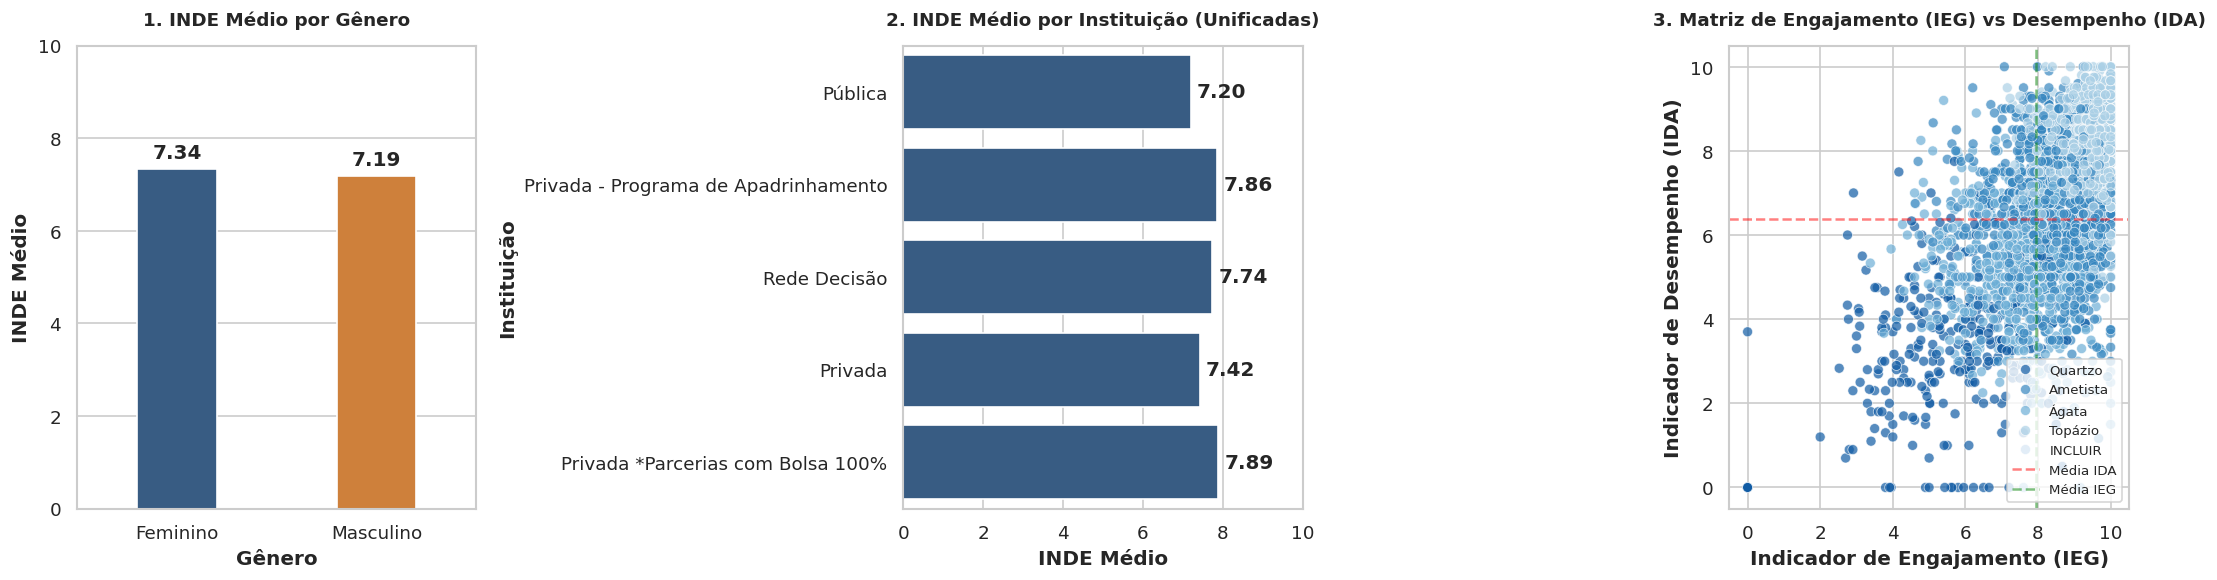

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

df_insights = df.copy()

# Unificação das Escolas (Pública + Escola Pública)
if "Instituicao_Ensino" in df_insights.columns:
    df_insights["Instituicao_Ensino"] = df_insights["Instituicao_Ensino"].astype(str).str.strip()
    df_insights["Instituicao_Ensino"] = df_insights["Instituicao_Ensino"].replace({
        "Escola Pública": "Pública",
        "Publica": "Pública"
    })

col_inde = "INDE" if "INDE" in df_insights.columns else "INDE_Atual"


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- GRÁFICO 1: GÊNERO ---
df_gen = df_insights.groupby("Gênero")[col_inde].mean().reset_index()
ax1 = sns.barplot(data=df_gen, x="Gênero", y=col_inde, hue="Gênero", palette=["#2B5C8F", "#E67E22"], legend=False, ax=axes[0], width=0.4)
axes[0].set_title("1. INDE Médio por Gênero", fontsize=11, fontweight="bold", pad=12)
axes[0].set_ylabel("INDE Médio", fontweight="bold")
axes[0].set_xlabel("Gênero", fontweight="bold")
axes[0].set_ylim(0, 10)

for p in ax1.patches:
    h = p.get_height()
    if h > 0:
        ax1.text(p.get_x() + p.get_width()/2, h + 0.15, f"{h:.2f}", ha="center", va="bottom", fontweight="bold")

# --- GRÁFICO 2: TOP INSTITUIÇÕES (UNIFICADAS) ---
top_inst = df_insights.groupby("Instituicao_Ensino")[col_inde].agg(["mean", "count"]).sort_values("count", ascending=False).head(5).reset_index()
ax2 = sns.barplot(data=top_inst, y="Instituicao_Ensino", x="mean", color="#2B5C8F", ax=axes[1])
axes[1].set_title("2. INDE Médio por Instituição (Unificadas)", fontsize=11, fontweight="bold", pad=12)
axes[1].set_xlabel("INDE Médio", fontweight="bold")
axes[1].set_ylabel("Instituição", fontweight="bold")
axes[1].set_xlim(0, 10)

for p in ax2.patches:
    w = p.get_width()
    if w > 0:
        ax2.text(w + 0.15, p.get_y() + p.get_height()/2, f"{w:.2f}", ha="left", va="center", fontweight="bold")

# --- GRÁFICO 3: MATRIZ IEG vs IDA ---
sns.scatterplot(data=df_insights, x="IEG", y="IDA", hue="Pedra_Atual", palette="Blues_r", alpha=0.7, ax=axes[2])
axes[2].set_title("3. Matriz de Engajamento (IEG) vs Desempenho (IDA)", fontsize=11, fontweight="bold", pad=12)
axes[2].set_xlabel("Indicador de Engajamento (IEG)", fontweight="bold")
axes[2].set_ylabel("Indicador de Desempenho (IDA)", fontweight="bold")
axes[2].axhline(df_insights["IDA"].mean(), color="red", linestyle="--", alpha=0.5, label="Média IDA")
axes[2].axvline(df_insights["IEG"].mean(), color="green", linestyle="--", alpha=0.5, label="Média IEG")
axes[2].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

**Leitura e sugestões para a Passos Mágicos:**

1. **Gênero:** a diferença de INDE médio entre meninas e meninos é pequena (≈0,15 ponto), não
   parece ser um fator relevante de desigualdade dentro do programa.
2. **Rede de ensino:** alunos em escolas privadas via apadrinhamento/bolsa têm INDE médio mais
   alto que os de escola pública — pode valer a pena entender se isso reflete o próprio efeito da
   bolsa/apadrinhamento (mais suporte) ou um viés de seleção dos alunos indicados a essas vagas.
3. **Fases intermediárias como ponto de atenção:** como visto na pergunta 2, o IDA cai nas fases
   mais avançadas — vale investigar reforço extra a partir da Fase 3.
4. **Sinal de risco antecipável:** o modelo da pergunta 9 mostra que dá para sinalizar, com boa
   antecedência, quais alunos correm risco de aumentar sua defasagem — abrindo espaço para
   intervenção preventiva (reforço escolar, acompanhamento psicopedagógico) antes que o problema
   se agrave, em vez de reagir depois que a defasagem já aumentou.